# Stroke Prediction Analysis

This notebook implements a complete data science workflow for stroke prediction, addressing class imbalance and comparing multiple models including Random Forest, Logistic Regression, XGBoost, and a Neural Network.

## 1. Imports & Setup

In [1]:
import os

# Allow multiple OpenMP runtimes to coexist
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from plotnine import *

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

#import tensorflow as tf
#from tensorflow import keras
#from tensorflow.keras import layers, callbacks

# Set random seed for reproducibility
np.random.seed(42)
#tf.random.set_seed(42)
print(f"PyTorch Device: {'mps' if torch.backends.mps.is_available() else 'cpu'}")

PyTorch Device: mps


## 2. Data Loading
Loading the dataset using Polars. We handle potential parsing errors by increasing the schema inference length and specifying null values.

In [2]:
# Load data with robust error handling settings
stroke_df = pl.read_csv(
    "healthcare-dataset-stroke-data.csv", 
    null_values=["N/A", ""],
    infer_schema_length=10000
)

print(f"Dataset shape: {stroke_df.shape}")
stroke_df.head()

Dataset shape: (5110, 12)


id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
i64,str,f64,i64,i64,str,str,str,f64,f64,str,i64
9046,"""Male""",67.0,0,1,"""Yes""","""Private""","""Urban""",228.69,36.6,"""formerly smoked""",1
51676,"""Female""",61.0,0,0,"""Yes""","""Self-employed""","""Rural""",202.21,null,"""never smoked""",1
31112,"""Male""",80.0,0,1,"""Yes""","""Private""","""Rural""",105.92,32.5,"""never smoked""",1
60182,"""Female""",49.0,0,0,"""Yes""","""Private""","""Urban""",171.23,34.4,"""smokes""",1
1665,"""Female""",79.0,1,0,"""Yes""","""Self-employed""","""Rural""",174.12,24.0,"""never smoked""",1


## 3. Data Cleaning & Feature Engineering

We perform the following steps:
1.  Impute missing BMI values with the median.
2.  Remove the single observation with "Other" gender.
3.  Create binary encodings for categorical variables.
4.  Engineer new features: Age groups, BMI categories, Glucose categories, and a composite Risk Score.
5.  Cast the target variable to integer.

In [3]:
import polars as pl
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# 1. Load and Initial Filter
# Fix: Added infer_schema_length to scan more rows and null_values to handle "N/A" strings
df = pl.read_csv(
    "healthcare-dataset-stroke-data.csv", 
    infer_schema_length=10000, 
    null_values=["N/A"]
)
df = df.filter(pl.col("gender") != "Other")

# 2. Prepare Data for KNN Imputation
# We use Pandas/Sklearn for this specific step as Polars lacks a native KNN Imputer.
pandas_df = df.to_pandas()

# Identify columns
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
num_cols = ['age', 'avg_glucose_level', 'hypertension', 'heart_disease']
target_impute = ['bmi']

# A. Temporarily Encode Categoricals (Ordinal is fine for distance approximation)
encoder = OrdinalEncoder()
df_encoded = pandas_df.copy()
df_encoded[cat_cols] = encoder.fit_transform(df_encoded[cat_cols])

# B. Scale Data (Crucial for KNN so 'age' doesn't dominate 'glucose')
scaler = StandardScaler()
cols_to_scale = num_cols + target_impute
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

# C. Apply KNN Imputer
imputer = KNNImputer(n_neighbors=5)
# We impute on everything except ID and Stroke
impute_data = df_encoded[cat_cols + num_cols + target_impute]
imputed_matrix = imputer.fit_transform(impute_data)

# D. Recover BMI
# The imputer returns an array in the same order. We extract the last column (BMI),
# inverse transform the scaling, and assign it back.
imputed_bmi_scaled = imputed_matrix[:, -1].reshape(-1, 1)

# Calculate mean/std manually from original pandas_df for inverse transform
# (We do this because we fit the scaler on multiple columns, making standard inverse_transform tricky for just one column)
bmi_mean = pandas_df['bmi'].mean()
bmi_std = pandas_df['bmi'].std()
final_bmi = (imputed_bmi_scaled * bmi_std) + bmi_mean

# 3. Back to Polars for Feature Engineering
# We inject the imputed BMI back into the original Polars DataFrame
stroke_final = (
    df
    .with_columns(pl.Series(name="bmi", values=final_bmi.flatten()))
    
    # --- Feature Engineering ---
    
    # 1. Binary Encodings
    .with_columns(
        pl.col("ever_married").replace({"Yes": 1, "No": 0}).cast(pl.Int8).alias("ever_married_binary"),
        pl.col("Residence_type").replace({"Urban": 1, "Rural": 0}).cast(pl.Int8).alias("residence_urban"),
        pl.col("gender").replace({"Male": 1, "Female": 0}).cast(pl.Int8).alias("gender_male"),
        pl.col("hypertension").cast(pl.Int8),
        pl.col("heart_disease").cast(pl.Int8),
        pl.col("stroke").cast(pl.Int8),
    )
    
    # 2. Binning (Age Groups)
    .with_columns(
        pl.when(pl.col("age") < 18).then(pl.lit("0-17"))
        .when(pl.col("age") < 40).then(pl.lit("18-39"))
        .when(pl.col("age") < 60).then(pl.lit("40-59"))
        .when(pl.col("age") < 80).then(pl.lit("60-79"))
        .otherwise(pl.lit("80+"))
        .alias("age_group")
    )
    
    # 3. BMI Categories
    .with_columns(
        pl.when(pl.col("bmi") < 18.5).then(pl.lit("Underweight"))
        .when(pl.col("bmi") < 25).then(pl.lit("Normal"))
        .when(pl.col("bmi") < 30).then(pl.lit("Overweight"))
        .otherwise(pl.lit("Obese"))
        .alias("bmi_category")
    )
    
    # 4. Glucose Categories
    .with_columns(
        pl.when(pl.col("avg_glucose_level") < 100).then(pl.lit("Normal"))
        .when(pl.col("avg_glucose_level") < 126).then(pl.lit("Prediabetic"))
        .otherwise(pl.lit("Diabetic"))
        .alias("glucose_category")
    )
    
    # 5. Risk Score Interaction
    .with_columns(
        (
            pl.col("hypertension") + 
            pl.col("heart_disease") + 
            (pl.col("age") >= 55).cast(pl.Int8) +
            (pl.col("avg_glucose_level") >= 126).cast(pl.Int8) +
            (pl.col("bmi") >= 30).cast(pl.Int8)
        ).alias("risk_score")
    )
    .drop("id")
)

# Export for non-CV models / EDA
stroke_final.write_csv("stroke_cleaned.csv")
print("Cleaned data exported with KNN imputation.")

Cleaned data exported with KNN imputation.


## 4. CV Pipeline



In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# Custom Feature Engineer for the Pipeline
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # Add Age Group
        X['age_group'] = pd.cut(X['age'], bins=[0,18,45,65,100], labels=['child','adult','senior','elderly'])
        # Add Risk Interaction (Glucose * Age)
        X['glucose_age_interaction'] = X['avg_glucose_level'] * X['age']
        return X

# 1. Prepare Data (Raw split)
# We use the pandas version of the raw filtered data
X = pandas_df.drop(['stroke', 'id'], axis=1)
y = pandas_df['stroke']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Define Preprocessing (Impute -> Scale -> Encode)
numeric_features = ['age', 'avg_glucose_level', 'bmi', 'glucose_age_interaction']
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'age_group']

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()), 
    ('imputer', KNNImputer(n_neighbors=5)) 
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# 4. Construct the Master CV Pipeline
cv_pipeline = ImbPipeline(steps=[
    ('feature_engineering', FeatureEngineer()),  # Creates columns
    ('preprocessor', preprocessor),              # Handles NaNs, Scaling, Encoding
    ('smote', SMOTE(random_state=42)),           # Resampling inside the fold
    ('model', RandomForestClassifier(random_state=42))
])

# 5. Run CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(cv_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"CV ROC-AUC Scores: {scores}")
print(f"Mean ROC-AUC: {scores.mean():.4f}")

CV ROC-AUC Scores: [0.79800771 0.83308162 0.81688748 0.74202059 0.77833012]
Mean ROC-AUC: 0.7937


## 5. Model Training & Evaluation

We train and compare three models: Random Forest, Logistic Regression, and XGBoost. All models are trained on the SMOTE-resampled training data.

In [5]:
from sklearn.model_selection import cross_validate
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 1. Define the Models (Same as your list)
# Note: For Stacking, we keep cv=5 internal, but we will also cross-validate the whole stack externally (Nested CV).
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('lr', LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
]

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=5, random_state=42, eval_metric="logloss"),
    "Stacking Classifier": StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression(), cv=5)
}

# 2. Define Scoring Metrics
# We want to track all these metrics during CV
scoring_metrics = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# 3. The CV Loop
cv_results_data = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Starting Cross-Validation Pipeline...")

for name, model in models.items():
    print(f"Evaluating {name}...")
    
    # Create a fresh pipeline for this specific model
    # We inject the model into the 'classifier' step defined in the previous solution
    current_pipeline = ImbPipeline(steps=[
        ('engineer', FeatureEngineer()),      # Feature Engineering
        ('preprocessor', preprocessor),       # Imputation & Scaling
        ('smote', SMOTE(random_state=42)),    # SMOTE (Inside CV!)
        ('classifier', model)                 # The specific model being tested
    ])
    
    # Run Cross-Validation
    # CRITICAL: We pass X_train, y_train (the raw data), NOT the resampled data.
    # The pipeline handles the resampling for us.
    scores = cross_validate(
        current_pipeline, 
        X_train, 
        y_train, 
        cv=cv, 
        scoring=scoring_metrics,
        n_jobs=-1  # Use all CPU cores
    )
    
    # Store the MEAN score across all 5 folds
    cv_results_data.append({
        "Model": name,
        "Accuracy": scores['test_accuracy'].mean(),
        "Recall": scores['test_recall'].mean(),
        "Precision": scores['test_precision'].mean(),
        "F1 Score": scores['test_f1'].mean(),
        "ROC-AUC": scores['test_roc_auc'].mean()
    })

# 4. Display Comparison
results_df = pd.DataFrame(cv_results_data)
print("\n=== Cross-Validation Performance (Mean of 5 Folds) ===")
print(results_df.round(4).sort_values(by='ROC-AUC', ascending=False))

Starting Cross-Validation Pipeline...
Evaluating Random Forest...
Evaluating Logistic Regression...
Evaluating XGBoost...
Evaluating Stacking Classifier...

=== Cross-Validation Performance (Mean of 5 Folds) ===
                 Model  Accuracy  Recall  Precision  F1 Score  ROC-AUC
1  Logistic Regression    0.6880  0.8644     0.1214    0.2129   0.8304
0        Random Forest    0.9246  0.0753     0.1082    0.0883   0.7937
2              XGBoost    0.8926  0.2215     0.1351    0.1670   0.7816
3  Stacking Classifier    0.9325  0.0651     0.1245    0.0849   0.6647


## 6. Elastic Net Grid Search

We perform a grid search to optimize the Logistic Regression model using Elastic Net regularization.

Running Grid Search on Pipeline...


/Users/kai/Documents/BSE/22E305_DataScience/DataScienceGang/project_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



=== BEST MODEL SELECTED ===
Parameters: {'classifier__C': 0.001, 'classifier__l1_ratio': 0.75}

=== TEST SET METRICS ===
Accuracy:  0.7162
ROC-AUC:   0.8382
Recall:    0.8200
Precision: 0.1273
F1 Score:  0.2204

Confusion Matrix:
[[691 281]
 [  9  41]]

Generating Coefficient Path...


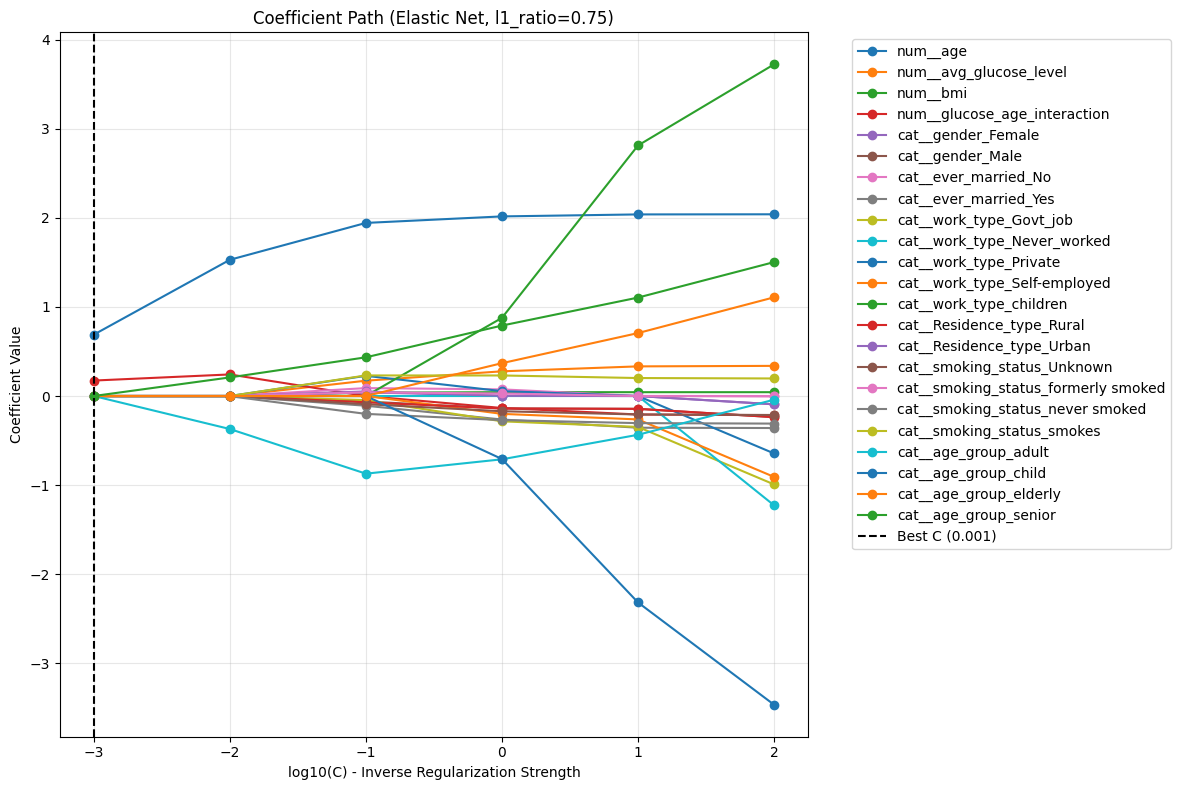

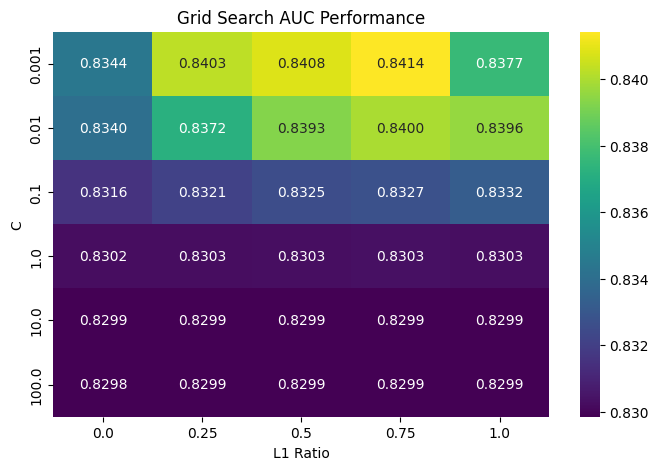

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 1. Setup Pipeline and Grid Search
# ---------------------------------------------------------
# We define the full pipeline including SMOTE
lr_pipeline = ImbPipeline(steps=[
    ('engineer', FeatureEngineer()),  # Our custom class from before
    ('preprocessor', preprocessor),   # The ColumnTransformer from before
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=2000,
        random_state=42,
        class_weight="balanced"
    ))
])

# Note the double underscore prefix 'classifier__' to target the step
param_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__l1_ratio": [0, 0.25, 0.5, 0.75, 1.0]
}

grid_search = GridSearchCV(
    lr_pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1
)

print("Running Grid Search on Pipeline...")
# CRITICAL: Pass raw X_train/y_train. The pipeline handles the rest.
grid_search.fit(X_train, y_train)

# 2. Extract Best Model and Evaluate
# ---------------------------------------------------------
best_pipeline = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f"\n=== BEST MODEL SELECTED ===")
print(f"Parameters: {best_params}")

# Generate Predictions (Pass raw X_test, pipeline handles transformation)
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# Calculate Metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
rec = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\n=== TEST SET METRICS ===")
print(f"Accuracy:  {acc:.4f}")
print(f"ROC-AUC:   {auc:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"Precision: {prec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

# 3. Generate Coefficient Path Diagram
# ---------------------------------------------------------
print("\nGenerating Coefficient Path...")

# We need to manually preprocess the data once so we can loop through C values quickly
# (Running the full pipeline 30 times would be slow)

# A. Extract steps from the fitted best pipeline
engineer_step = best_pipeline.named_steps['engineer']
preprocessor_step = best_pipeline.named_steps['preprocessor']
smote_step = best_pipeline.named_steps['smote']

# B. Transform X_train to the state the classifier sees
X_eng = engineer_step.transform(X_train)         # Add features
X_scaled = preprocessor_step.transform(X_eng)    # Scale/Encode
X_resampled, y_resampled = smote_step.fit_resample(X_scaled, y_train) # Apply SMOTE

# C. Get Feature Names
try:
    feature_names = preprocessor_step.get_feature_names_out()
except:
    feature_names = [f"Feature {i}" for i in range(X_resampled.shape[1])]

Cs = param_grid['classifier__C']
best_l1 = best_params['classifier__l1_ratio']
coeffs = []

# Loop through C values using just the classifier part
for c in Cs:
    clf = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        C=c,
        l1_ratio=best_l1,
        max_iter=2000,
        random_state=42,
        class_weight="balanced"
    )
    # Fit on the pre-processed, resampled data
    clf.fit(X_resampled, y_resampled)
    coeffs.append(clf.coef_.ravel())

coeffs = np.array(coeffs)

# Plotting
plt.figure(figsize=(12, 8))
for i in range(coeffs.shape[1]):
    plt.plot(np.log10(Cs), coeffs[:, i], marker='o', label=feature_names[i])

best_c = best_params['classifier__C']
plt.axvline(x=np.log10(best_c), color='black', linestyle='--', label=f"Best C ({best_c})")

plt.title(f"Coefficient Path (Elastic Net, l1_ratio={best_l1})")
plt.xlabel("log10(C) - Inverse Regularization Strength")
plt.ylabel("Coefficient Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Standard Heatmap
# ---------------------------------------------------------
results_pd = pd.DataFrame(grid_search.cv_results_)
pivot_table = results_pd.pivot(index="param_classifier__C", columns="param_classifier__l1_ratio", values="mean_test_score")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="viridis")
plt.title("Grid Search AUC Performance")
plt.xlabel("L1 Ratio")
plt.ylabel("C")
plt.show()

## 7. Lasso Coefficient Analysis

We analyze the coefficients of the best Elastic Net model to see which features were shrunk to zero.

In [7]:
import shap

# --- SHAP ANALYSIS (Suggestion 4) ---
# We use a Random Forest model for the explanation as it handles non-linearities well.
# We retrain a fresh instance on the processed data to ensure the explainer has full access.

print("Training Explainer Model (Random Forest)...")
rf_explainer = RandomForestClassifier(n_estimators=100, random_state=42)
rf_explainer.fit(X_train_resampled, y_train_resampled)

# Initialize SHAP Tree Explainer
explainer = shap.TreeExplainer(rf_explainer)

# Calculate SHAP values for the test set
# We take a sample of the test set if it's too large, but here it's small enough.
shap_values = explainer.shap_values(X_test_processed)

# Get feature names for the plot
# We need to combine numeric, binary, and one-hot encoded categorical names
cat_feature_names = list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
# Note: We added interaction terms in the previous step, so we need to ensure feature names align.
# The 'numeric_features' list in Cell 5 needs to match what was used in 'ColumnTransformer'.
# Assuming 'preprocessor' was fitted on the DataFrame that INCLUDED the interaction terms:
feature_names_all = numeric_features + binary_features + cat_feature_names

print("Generating SHAP Summary Plot...")
# Summary plot for the positive class (Stroke = 1)
shap.summary_plot(shap_values[1], X_test_processed, feature_names=feature_names_all)

# Optional: Force plot for a single high-risk prediction
# shap.force_plot(explainer.expected_value[1], shap_values[1][0,:], X_test_processed[0,:], feature_names=feature_names_all, matplotlib=True)

Training Explainer Model (Random Forest)...


NameError: name 'X_train_resampled' is not defined

## 8. Neural Network

We implement a binary classification neural network using TensorFlow/Keras. We check for Apple Metal (MPS) acceleration availability.

Loading data...
Preprocessing & SMOTE...
Running on device: mps
Starting Training...
Epoch 10/100, Loss: 0.5145
Epoch 20/100, Loss: 0.4572
Epoch 30/100, Loss: 0.4200
Epoch 40/100, Loss: 0.3905
Epoch 50/100, Loss: 0.3551
Epoch 60/100, Loss: 0.3330
Epoch 70/100, Loss: 0.3141
Epoch 80/100, Loss: 0.2995
Epoch 90/100, Loss: 0.2888
Epoch 100/100, Loss: 0.2664

FINAL RESULTS
ROC-AUC:   0.7700
Accuracy:  0.8190
Recall:    0.4600
Precision: 0.1271
F1 Score:  0.1991
------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.84      0.90       972
         1.0       0.13      0.46      0.20        50

    accuracy                           0.82      1022
   macro avg       0.55      0.65      0.55      1022
weighted avg       0.93      0.82      0.86      1022



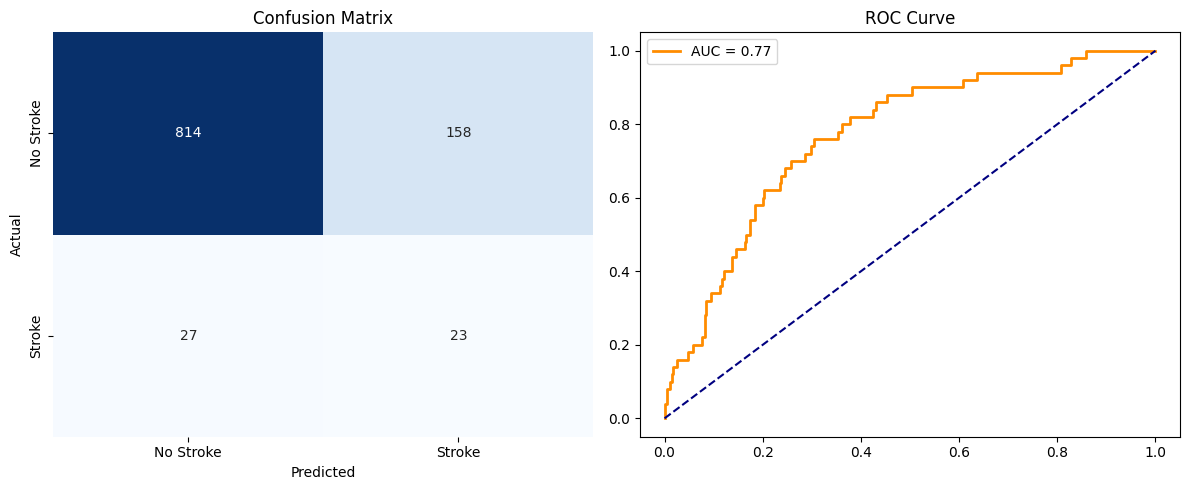

In [17]:
import polars as pl
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    roc_auc_score, recall_score, accuracy_score, precision_score, f1_score,
    classification_report, confusion_matrix, roc_curve
)

# ---------------------------------------------------------
# 1. Data Loading (Polars)
# ---------------------------------------------------------
print("Loading data...")
df = pl.read_csv(
    "healthcare-dataset-stroke-data.csv", 
    infer_schema_length=10000, 
    null_values=["N/A"]
)
df = df.filter(pl.col("gender") != "Other")
pandas_df = df.to_pandas()

# 2. Train/Test Split
X = pandas_df.drop(['stroke', 'id'], axis=1)
y = pandas_df['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ---------------------------------------------------------
# 3. Feature Engineering
# ---------------------------------------------------------
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        # Bin Age (Strongest Predictor)
        X['age_group'] = pd.cut(X['age'], bins=[0,18,45,65,100], labels=['child','adult','senior','elderly'])
        
        # Log Transform Glucose & BMI to reduce skewness
        X['log_glucose'] = np.log1p(X['avg_glucose_level'])
        X['log_bmi'] = np.log1p(X['bmi'])
        
        # Interaction: High Glucose in Elderly is dangerous
        X['glucose_age'] = X['avg_glucose_level'] * X['age']
        
        return X

numeric_features = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'glucose_age', 'log_glucose', 'log_bmi']
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'age_group']

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()), 
    ('imputer', KNNImputer(n_neighbors=5)) 
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# ---------------------------------------------------------
# 4. Processing & SMOTE
# ---------------------------------------------------------
print("Preprocessing & SMOTE...")
fe = FeatureEngineer()
X_train_eng = fe.fit_transform(X_train)
X_test_eng = fe.transform(X_test)

X_train_processed = preprocessor.fit_transform(X_train_eng)
X_test_processed = preprocessor.transform(X_test_eng)

# SMOTE: Create synthetic examples to balance data 50/50
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

# Convert to Tensors (MPS/Float32 compatible)
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

X_train_tensor = torch.tensor(X_train_resampled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_resampled, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# ---------------------------------------------------------
# 5. Model Definition
# ---------------------------------------------------------
class StrokeClassifier(nn.Module):
    def __init__(self, input_dim):
        super(StrokeClassifier, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(input_dim, 128),     # Increased width
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),               # Higher dropout for regularization
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.main(x)

model = StrokeClassifier(input_dim=X_train_resampled.shape[1]).to(device)

# KEY CORRECTION: 
# Since SMOTE makes the data 50/50, pos_weight should be close to 1.0.
# We set it to 2.0 to give a *slight* preference to Recall without destroying Accuracy.
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0], dtype=torch.float32).to(device))
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# ---------------------------------------------------------
# 6. Training with Early Stopping
# ---------------------------------------------------------
print("Starting Training...")
epochs = 100
loss_history = []
best_loss = float('inf')
patience = 10
patience_counter = 0

model.train()
for epoch in range(epochs): 
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)
    
    # Simple Early Stopping Check
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        patience_counter = 0
    else:
        patience_counter += 1
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")
        
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# ---------------------------------------------------------
# 7. Final Evaluation
# ---------------------------------------------------------
model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    logits = model(X_test_tensor)
    y_pred_probs = torch.sigmoid(logits).cpu().numpy()
    y_true = y_test_tensor.cpu().numpy()

# Standard Threshold
y_pred_labels = (y_pred_probs >= 0.5).astype(int)

# Metrics
roc = roc_auc_score(y_true, y_pred_probs)
rec = recall_score(y_true, y_pred_labels)
acc = accuracy_score(y_true, y_pred_labels)
prec = precision_score(y_true, y_pred_labels)
f1 = f1_score(y_true, y_pred_labels)

print("\n" + "="*30)
print("FINAL RESULTS")
print("="*30)
print(f"ROC-AUC:   {roc:.4f}")
print(f"Accuracy:  {acc:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"Precision: {prec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("-" * 30)
print("Classification Report:")
print(classification_report(y_true, y_pred_labels))

# Plotting
plt.figure(figsize=(12, 5))

# Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_true, y_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()